In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset (replace with your file path)
df = pd.read_csv("Superstore.csv")

# Check first few rows
print(df.head())


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [2]:
# Check column names, data types, missing values
print(df.info())

# Summary statistics for numerical columns
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [3]:
print(df.isnull().sum())


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [5]:
# dayfirst=True tells pandas the format is day/month/year
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)



In [6]:
print(df['Order Date'].head())
print(df['Order Date'].dtype)  # should show datetime64[ns]


0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: Order Date, dtype: datetime64[ns]
datetime64[ns]


C:\Users\SUPER\AppData\Local\Temp\ipykernel_11024\2868945341.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()


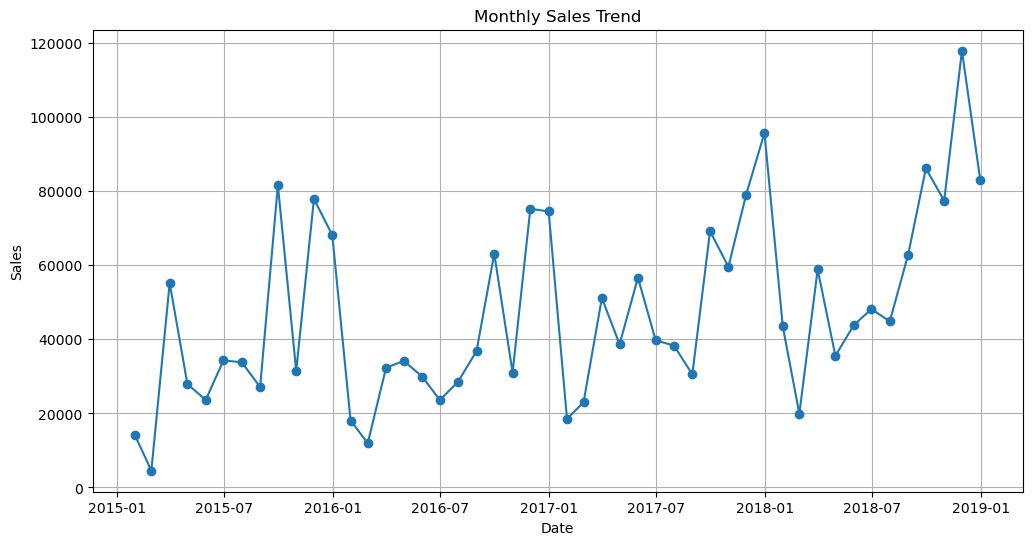

In [7]:
# Aggregate monthly sales
df_monthly = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()

# Plot monthly sales trend
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(df_monthly['Order Date'], df_monthly['Sales'], marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()


In [8]:
# Check missing values
print(df.isnull().sum())

# Fill missing Sales with 0 (or you can drop if few)
df['Sales'] = df['Sales'].fillna(0)


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [10]:
# Group by month
df_monthly = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()

# Optional: rename for Prophet
df_monthly = df_monthly.rename(columns={'Order Date':'ds', 'Sales':'y'})

print(df_monthly.head())


          ds          y
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


In [11]:
# Month and Year columns
df_monthly['Month'] = df_monthly['ds'].dt.month
df_monthly['Year'] = df_monthly['ds'].dt.year

# Lag features (previous month sales)
df_monthly['Lag1'] = df_monthly['y'].shift(1)
df_monthly['Lag2'] = df_monthly['y'].shift(2)

# Moving average (3-month)
df_monthly['MA_3'] = df_monthly['y'].rolling(3).mean()


In [12]:
# If not installed, run this in your terminal or Jupyter:
# pip install prophet

from prophet import Prophet
import matplotlib.pyplot as plt


In [13]:
# Initialize model
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)

# Fit the model
model.fit(df_monthly)


09:11:49 - cmdstanpy - INFO - Chain [1] start processing
09:11:51 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
# Forecast next 12 months
future = model.make_future_dataframe(periods=12, freq='ME')

# Predict
forecast = model.predict(future)


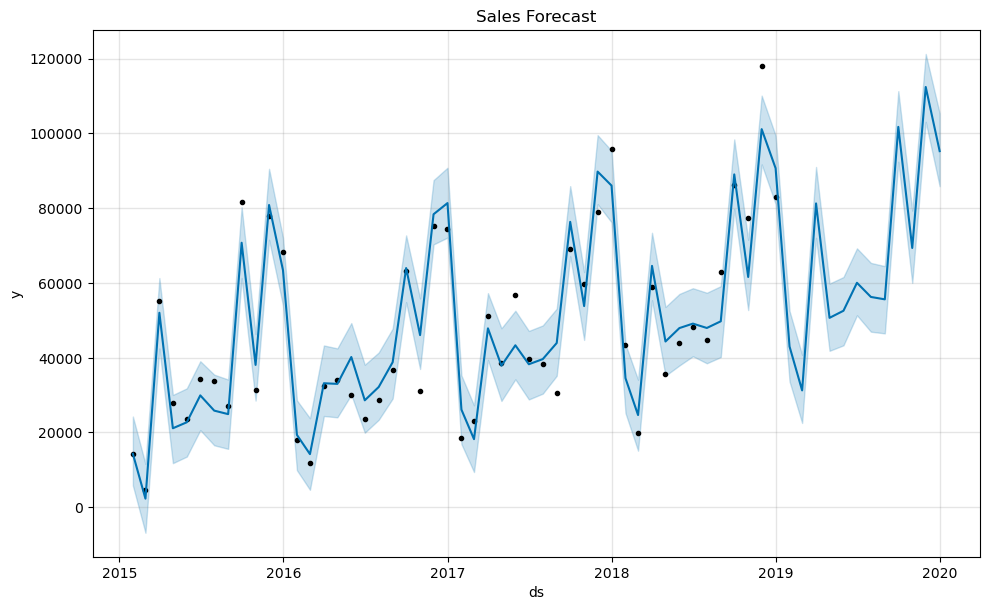

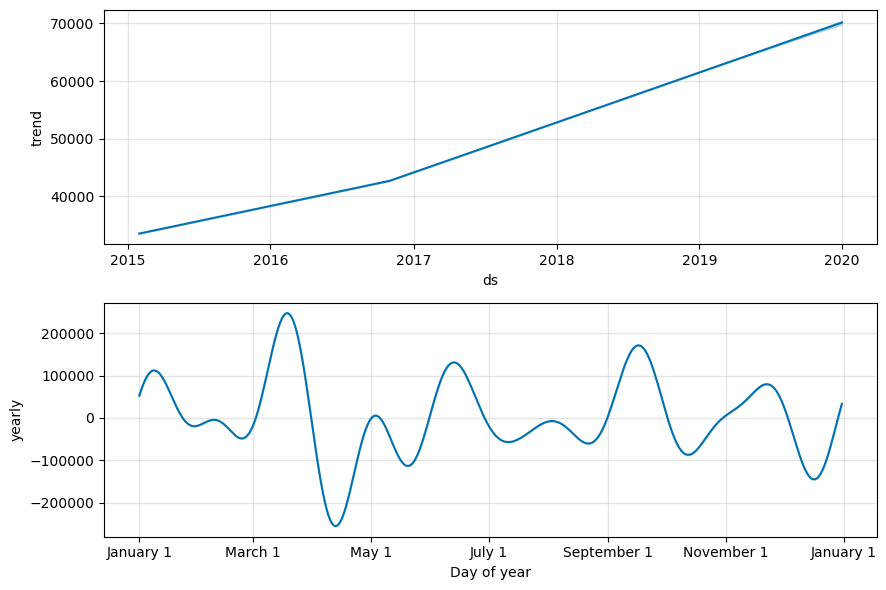

In [16]:
# Forecast plot
model.plot(forecast)
plt.title("Sales Forecast")
plt.show()

# Optional: components plot (trend + yearly seasonality)
model.plot_components(forecast)
plt.show()


In [17]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv("forecast.csv", index=False)


In [19]:
# Monthly sales by Category (example)
df_category = df.groupby([pd.Grouper(key='Order Date', freq='ME'), 'Category'])['Sales'].sum().reset_index()
df_category.rename(columns={'Order Date':'ds', 'Sales':'y'}, inplace=True)
df_category.to_csv("monthly_category_sales.csv", index=False)


In [21]:
# Step 0: Import libraries
import pandas as pd
from prophet import Prophet

# Step 1: Load datasets
superstore = pd.read_csv("Superstore.csv")
forecast = pd.read_csv("forecast.csv")  # your Prophet forecast
monthly_category = pd.read_csv("monthly_category_sales.csv")  # optional for category filter

# Step 2: Prepare monthly actual sales from Superstore
superstore['Order Date'] = pd.to_datetime(superstore['Order Date'], dayfirst=True)
df_monthly = superstore.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()
df_monthly = df_monthly.rename(columns={'Order Date':'ds', 'Sales':'Actual_Sales'})

# Step 3: Merge monthly actual sales with forecast
# Ensure 'ds' in forecast is datetime
forecast['ds'] = pd.to_datetime(forecast['ds'])
merged = pd.merge(df_monthly, forecast[['ds','yhat','yhat_lower','yhat_upper']], on='ds', how='outer')

# Step 4: Optional - add category info (aggregated monthly)
# monthly_category already has 'ds', 'Category', 'y'
monthly_category['ds'] = pd.to_datetime(monthly_category['ds'])
category_agg = monthly_category.groupby('ds')['y'].sum().reset_index()
category_agg = category_agg.rename(columns={'y':'Category_Sales'})

# Merge category sales
merged = pd.merge(merged, category_agg, on='ds', how='left')

# Step 5: Save final dataset for Power BI
merged.to_csv("final_dashboard_data.csv", index=False)
print("Final dashboard data saved as 'final_dashboard_data.csv'")
print(merged.head())


Final dashboard data saved as 'final_dashboard_data.csv'
          ds  Actual_Sales          yhat    yhat_lower    yhat_upper  \
0 2015-01-31     14205.707  14300.788630   5828.228521  24265.598161   
1 2015-02-28      4519.892   2292.490775  -6833.573875  11582.838842   
2 2015-03-31     55205.797  52016.921025  42473.251268  61300.156745   
3 2015-04-30     27906.855  21123.413134  11791.530175  30035.599896   
4 2015-05-31     23644.303  22726.497781  13544.797542  31801.553271   

   Category_Sales  
0       14205.707  
1        4519.892  
2       55205.797  
3       27906.855  
4       23644.303  
